In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [3]:
BASE_DIR=Path("..")/'data'
train_transaction = pd.read_csv(BASE_DIR/'train_transaction.csv')
test_transaction = pd.read_csv(BASE_DIR/'test_transaction.csv')

In [4]:
v_cols = [col for col in train_transaction.columns if col.startswith('V')]
v_features = train_transaction[v_cols]

In [5]:
# Take a look at the first few rows
print("First 5 Rows of V-Features")
display(v_features.head())

# Check how many missing values we are dealing with
missing_counts = v_features.isna().sum()
print(f"Features with 0 missing values: {(missing_counts == 0).sum()}")
print(f"Features with missing values: {(missing_counts > 0).sum()}")
print(f"Maximum missing values in a single V-column: {missing_counts.max():,}")

First 5 Rows of V-Features


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Features with 0 missing values: 0
Features with missing values: 339
Maximum missing values in a single V-column: 508,595


In [6]:
# Calculate the proportion of NAs for every column (returns a decimal between 0.0 and 1.0)
na_proportions = v_features.isna().mean()

# Filter for only the columns that are missing 50% or more of their data
missing_70_plus = na_proportions[na_proportions >= 0.76]
missing_80_plus = na_proportions[na_proportions >= 0.80]
missing_90_plus = na_proportions[na_proportions >= 0.90]

# Sort them in descending order so the emptiest columns are at the top
missing_70_plus = missing_70_plus.sort_values(ascending=False)
missing_80_plus = missing_80_plus.sort_values(ascending=False)
missing_90_plus = missing_90_plus.sort_values(ascending=False)


print(f"Total V-columns missing >= 70% data: {len(missing_70_plus)} out of {len(v_features.columns)}")
print(f"Total V-columns missing >= 80% data: {len(missing_80_plus)} out of {len(v_features.columns)}")
print(f"Total V-columns missing >= 90% data: {len(missing_90_plus)} out of {len(v_features.columns)}")

Total V-columns missing >= 70% data: 159 out of 339
Total V-columns missing >= 80% data: 47 out of 339
Total V-columns missing >= 90% data: 0 out of 339


Now we can drop 159 columns! Basically because there are so many NAs, it would not be a good idea to imputate them: we could run a KKN imputation but that would take hours and so much RAM because of our 500k rows. Also dropping these columns would allow us to reduce the size of the dataset. I am only running this on the v-features for now, but this is an approach that we should apply to various columns!

In [7]:
# Find columns missing 70% or more
threshold = 0.70
na_proportions = v_features.isna().mean()
cols_to_drop = na_proportions[na_proportions >= threshold].index

# Drop them
v_features_filtered = v_features.drop(columns=cols_to_drop)

# Apply attribute imputation and scaling
imputer = SimpleImputer(strategy='median')
v_features_imputed = imputer.fit_transform(v_features_filtered)
scaler = StandardScaler()
v_scaled = scaler.fit_transform(v_features_imputed)

print(f"Initial V-features count: {v_features.shape[1]}")
print(f"Dropped {len(cols_to_drop)} columns.")
print(f"Remaining V-features count: {v_features_filtered.shape[1]}")
#print(f"Final array shape: {v_scaled.shape}")

Initial V-features count: 339
Dropped 159 columns.
Remaining V-features count: 180


In [8]:
v_scaled_df = pd.DataFrame(v_scaled, columns=v_features_filtered.columns)
corr_matrix = v_scaled_df.corr().abs()

# Select upper triangle of correlation matrix (to avoid checking the same pair twice)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find index of columns with correlation greater than 0.90
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
print(f"Number of redundant V-columns to drop: {len(to_drop)}")

# Drop the columns from our scaled dataframe
v_features_final = v_scaled_df.drop(columns=to_drop)

Number of redundant V-columns to drop: 80


In [9]:
v_features_final

,V1,V2,V3,V4,V6,V7,V8,V9,V10,V12,...,V302,V303,V305,V310,V311,V312,V313,V314,V319,V320
0,0.005365,-0.135535,-0.174217,0.246322,-0.137377,-0.171279,-0.107532,-0.132158,-0.550896,0.768955,...,-0.522440,-0.454030,-0.002603,-0.334844,-0.041047,-0.227583,-0.222385,-0.249222,-0.055287,-0.088855
1,0.005365,-0.135535,-0.174217,0.246322,-0.137377,-0.171279,-0.107532,-0.132158,-0.550896,-1.235771,...,-0.522440,-0.454030,-0.002603,-0.334844,-0.041047,-0.227583,-0.222385,-0.249222,-0.055287,-0.088855
2,0.005365,-0.135535,-0.174217,0.246322,-0.137377,-0.171279,-0.107532,-0.132158,-0.550896,0.768955,...,-0.522440,-0.454030,-0.002603,-0.334844,-0.041047,-0.227583,-0.222385,-0.249222,-0.055287,-0.088855
3,0.005365,-0.135535,-0.174217,0.246322,-0.137377,-0.171279,-0.107532,-0.132158,-0.550896,0.768955,...,-0.522440,-0.454030,-0.002603,0.668046,-0.041047,0.556723,-0.222385,-0.249222,-0.055287,-0.088855
4,0.005365,-0.135535,-0.174217,0.246322,-0.137377,-0.171279,-0.107532,-0.132158,-0.550896,0.768955,...,1.552745,1.149555,-0.002603,-0.334844,-0.041047,-0.227583,-0.222385,-0.249222,-0.055287,-0.088855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,0.005365,-0.135535,-0.174217,-2.797414,-0.137377,-0.171279,-0.107532,-0.132158,-0.550896,2.773680,...,-0.522440,-0.454030,-0.002603,-0.199001,-0.041047,-0.227583,0.278111,0.027236,-0.055287,-0.088855
590536,0.005365,-0.135535,-0.174217,0.246322,-0.137377,-0.171279,-0.107532,-0.132158,-0.550896,0.768955,...,-0.522440,-0.454030,-0.002603,-0.334844,-0.041047,-0.227583,-0.222385,-0.249222,-0.055287,-0.088855
590537,0.005365,-0.135535,-0.174217,0.246322,-0.137377,-0.171279,-0.107532,-0.132158,1.702133,0.768955,...,-0.522440,-0.454030,-0.002603,-0.334844,-0.041047,-0.227583,-0.222385,-0.249222,-0.055287,-0.088855
590538,0.005365,-0.135535,-0.174217,3.290059,-0.137377,-0.171279,-0.107532,-0.132158,-0.550896,0.768955,...,-0.522440,-0.454030,-0.002603,1.561866,-0.041047,0.452149,3.091642,3.610817,-0.055287,-0.088855


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Use clean non-V features (TransactionAmt, ProductCD, etc.)
# Drop 'isFraud' (target) and 'TransactionID' (not a feature)
X_base = train_transaction.drop(['isFraud', 'TransactionID'], axis=1, errors='ignore')

# Join with v_features_final (the ones pruned from the huge heatmap)
# Since they are both in the same order, we can concatenate horizontally
X = pd.concat([X_base.reset_index(drop=True), v_features_final.reset_index(drop=True)], axis=1)
y = train_transaction['isFraud'].values

print(f"Final Feature Matrix Shape: {X.shape}")

# Instead of a loop for LabelEncoder, we'll identify objects and convert them
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].astype('category').cat.codes

# We use 'stratify=y' because fraud is rare (imbalanced classes)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# We set max_depth to prevent the tree from growing infinitely (overfitting)
#clf = DecisionTreeClassifier(max_depth=10, random_state=42, class_weight='balanced')
#clf.fit(X_train, y_train)

#y_pred = clf.predict(X_test)
#print("Model Performance")
#print(classification_report(y_test, y_pred))

Final Feature Matrix Shape: (590540, 492)


Basic Decision Tree Accuracy: 0.97
Basic Decision Tree F1-Score: 0.56
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    113975
           1       0.56      0.56      0.56      4133

    accuracy                           0.97    118108
   macro avg       0.77      0.77      0.77    118108
weighted avg       0.97      0.97      0.97    118108

Depth: 10, F1 score: 0.24
Depth: 15, F1 score: 0.31
Depth: 20, F1 score: 0.37
Depth: 25, F1 score: 0.42


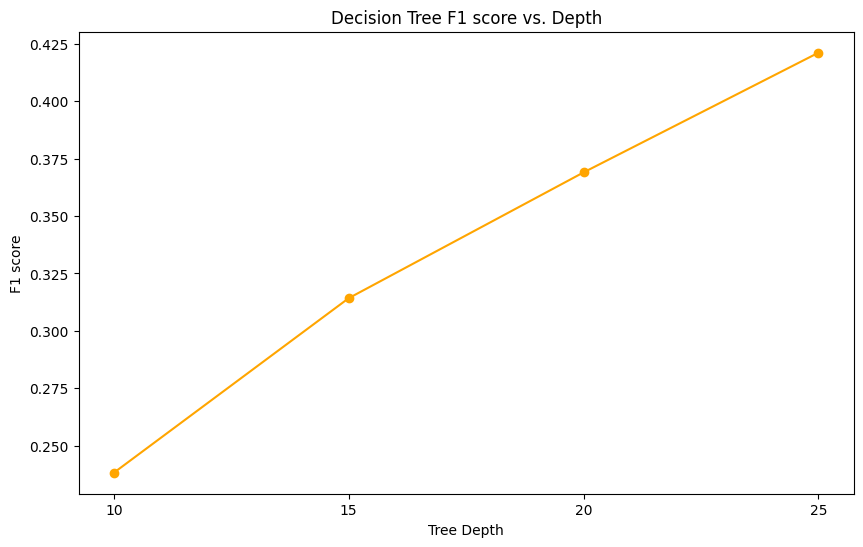

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
import matplotlib.pyplot as plt
from sklearn import tree

# Step 1: Train a basic Decision Tree
clf = DecisionTreeClassifier(criterion='entropy', class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)

# Step 2: Predict on test data and measure accuracy
y_pred = clf.predict(X_test) # Predict class labels
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Basic Decision Tree Accuracy: {accuracy:.2f}')
print(f'Basic Decision Tree F1-Score: {f1:.2f}')
print(classification_report(y_test, y_pred))

# Step 3: Experiment with different tree depths
depths = [10, 15, 20, 25]
f1_scores = []
for depth in depths:
    clf = DecisionTreeClassifier(criterion='entropy', class_weight='balanced', max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    current_f1 = f1_score(y_test, y_pred)
    f1_scores.append(current_f1)
    print(f'Depth: {depth}, F1 score: {current_f1:.2f}')

# Step 4: Plot accuracies vs. tree depths
plt.figure(figsize=(10, 6))
plt.plot([str(d) for d in depths], f1_scores, marker='o', color='orange')
plt.title('Decision Tree F1 score vs. Depth')
plt.xlabel('Tree Depth')
plt.ylabel('F1 score')
plt.show()
